# Model Testing & Exploration Notebook

**Project:** Deep Learning for Content Moderation on Shareish Platform  
**Purpose:** Test all candidate models and compare their performance comprehensively  
**Date:** November 2025

---

## Overview

This notebook systematically tests all candidate content moderation models:

1. **Detoxify Models** - Fast baseline toxicity detection
   - Detoxify Multilingual
   - Detoxify Unbiased

2. **Llama Guard Models** - Meta's safety models with French support
   - Llama Guard 3-1B
   - Llama Guard 3-8B

3. **ShieldGemma Models** - Google's safety classification models
   - ShieldGemma 2B
   - ShieldGemma 9B

4. **Mistral Model** - Mistral 7B Instruct with moderation prompt

5. **Specialized Content Moderation Models**
   - EthicalEye (autopilot-ai/EthicalEye)
   - KoalaAI (KoalaAI/Text-Moderation)
   - CitizenLab (citizenlab/twitter-xlm-roberta-base-sentiment-finetunned)

**Evaluation Dimensions:**
- Classification Performance (Accuracy, Precision, Recall, F1)
- Confusion Matrix Analysis (TPR, FPR, TNR, FNR)
- Runtime Efficiency (Inference time per sample)
- Resource Usage (GPU memory, CPU utilization)
- Energy Consumption (Estimated)
- Error Handling (Failed predictions)

## 1. Setup & Imports

In [1]:
# Standard library imports
import json
import time
import os
import sys
import psutil
import platform
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import List, Dict, Tuple, Optional
from datetime import datetime, timedelta

# Scientific computing
import numpy as np
import pandas as pd

# Machine learning
import torch
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix, classification_report
)

# Deep learning frameworks
from transformers import (
    AutoTokenizer, 
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    pipeline
)

# Detoxify model
from detoxify import Detoxify

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("✅ All imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")

/home/sural/anaconda3/envs/thesis/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All imports successful
PyTorch version: 2.5.1
CUDA available: True
GPU: NVIDIA RTX A5000
GPU Memory: 23.69 GB


## 2. Configuration

In [2]:
# Paths configuration
BASE_DIR = Path("/home/sural/datasets")
OPENAI_DIR = BASE_DIR / "openai"
DATASET_PATH = OPENAI_DIR / "samples-1680.jsonl"

# Output directory
OUTPUT_DIR = Path("/home/sural/code/results/model_exploration")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Model configuration
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
TOXICITY_THRESHOLD = 0.5

# Testing configuration
MAX_SAMPLES = None  # Set to None for full dataset, or a number for quick testing
BATCH_SIZE = 8  # For batch processing models

print(f"Device: {DEVICE}")
print(f"Dataset path: {DATASET_PATH}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Max samples: {MAX_SAMPLES if MAX_SAMPLES else 'All'}")

Device: cuda
Dataset path: /home/sural/datasets/openai/samples-1680.jsonl
Output directory: /home/sural/code/results/model_exploration
Max samples: All


## 3. Data Structures

In [3]:
@dataclass
class ModelInfo:
    """Model metadata and configuration"""
    name: str
    model_type: str  # 'detoxify', 'llama_guard', 'shieldgemma', 'mistral'
    model_id: str  # HuggingFace model ID or identifier
    size_params: str  # e.g., '1B', '8B', 'unknown'
    supports_french: bool
    architecture: str  # e.g., 'BERT', 'Llama', 'Gemma', 'Mistral'
    description: str

@dataclass
class ModelMetrics:
    """Model performance metrics"""
    model_name: str
    accuracy: float
    precision: float
    recall: float
    f1: float
    
    # Confusion matrix components
    true_positives: int
    false_positives: int
    true_negatives: int
    false_negatives: int
    
    # Rates
    true_positive_rate: float  # TPR / Recall / Sensitivity
    false_positive_rate: float  # FPR
    true_negative_rate: float  # TNR / Specificity
    false_negative_rate: float  # FNR
    
    # Performance metrics
    avg_inference_time_ms: float
    total_inference_time_seconds: float
    samples_per_second: float
    
    # Resource usage
    gpu_memory_mb: float
    cpu_percent_avg: float
    
    # Energy (estimated)
    energy_consumed_kwh: float
    co2_emissions_kg: float
    
    # Error handling
    errors: int
    error_rate: float

print("✅ Data structures defined")

✅ Data structures defined


## 4. Utility Functions

In [ ]:
def load_dataset(path: Path, max_samples: Optional[int] = None) -> List[Dict]:
    """Load OpenAI moderation dataset and convert to binary labels"""
    samples = []
    with open(path, 'r') as f:
        for line in f:
            sample = json.loads(line)
            # Convert multi-label to binary: unsafe if ANY category is 1
            label_keys = ['S', 'H', 'V', 'HR', 'SH', 'S3', 'H2', 'V2']
            label_values = [sample.get(k, 0) for k in label_keys if k in sample]
            sample['label'] = 1 if any(label_values) else 0
            samples.append(sample)
    
    if max_samples:
        samples = samples[:max_samples]
    
    print(f"✅ Loaded {len(samples)} samples")
    print(f"   Safe samples: {sum(1 for s in samples if s['label'] == 0)}")
    print(f"   Unsafe samples: {sum(1 for s in samples if s['label'] == 1)}")
    return samples

def compute_metrics(y_true: List[int], y_pred: List[int]) -> Tuple:
    """Compute comprehensive classification metrics - handles both binary and multiclass"""
    if len(y_true) == 0:
        return tuple([0.0] * 12)
    
    # Convert to numpy for easier handling
    import numpy as np
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Check if binary or multiclass
    unique_true = np.unique(y_true)
    unique_pred = np.unique(y_pred)
    unique_all = np.unique(np.concatenate([unique_true, unique_pred]))
    
    # Determine if binary (0,1) or multiclass
    is_binary = len(unique_all) <= 2 and set(unique_all).issubset({0, 1})
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    
    if is_binary:
        # Binary classification
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        # Confusion matrix for binary
        cm = confusion_matrix(y_true, y_pred)
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
        else:
            # Handle case where only one class predicted
            tn = fp = fn = tp = 0
            if cm.shape == (1, 1):
                if unique_all[0] == 0:
                    tn = cm[0, 0]
                else:
                    tp = cm[0, 0]
    else:
        # Multiclass - use weighted averaging
        precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        
        # For multiclass, confusion matrix won't give us simple tp/tn/fp/fn
        # We'll compute them as aggregates for the "positive" class (class 1 if it exists)
        if 1 in unique_all:
            # Treat class 1 as positive, others as negative
            y_true_binary = (y_true == 1).astype(int)
            y_pred_binary = (y_pred == 1).astype(int)
            cm = confusion_matrix(y_true_binary, y_pred_binary)
            if cm.shape == (2, 2):
                tn, fp, fn, tp = cm.ravel()
            else:
                tn = fp = fn = tp = 0
        else:
            # No class 1, can't compute binary metrics
            tn = fp = fn = tp = 0
    
    # Rates
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    
    return accuracy, precision, recall, f1, tpr, fpr, tnr, fnr, tp, fp, tn, fn

def estimate_energy(gpu_memory_mb: float, runtime_seconds: float, 
                   cpu_percent: float, gpu_available: bool) -> Tuple[float, float]:
    """Estimate energy consumption and CO2 emissions"""
    runtime_hours = runtime_seconds / 3600
    
    # GPU energy
    gpu_energy_kwh = 0.0
    if gpu_available and gpu_memory_mb > 0:
        if gpu_memory_mb < 4000:
            estimated_gpu_watts = 50
        elif gpu_memory_mb < 10000:
            estimated_gpu_watts = 150
        else:
            estimated_gpu_watts = 250
        gpu_energy_kwh = (estimated_gpu_watts / 1000) * runtime_hours
    
    # CPU energy
    avg_cpu_tdp_watts = 95
    cpu_energy_kwh = (avg_cpu_tdp_watts * (cpu_percent / 100) / 1000) * runtime_hours
    
    total_energy_kwh = gpu_energy_kwh + cpu_energy_kwh
    co2_kg = total_energy_kwh * 0.475  # IEA 2023 global average
    
    return total_energy_kwh, co2_kg

def format_runtime(seconds: float) -> str:
    """Format seconds as HH:MM:SS"""
    return str(timedelta(seconds=int(seconds)))

print("✅ Utility functions defined")

## 5. Model Testing Functions

### 5.1 Detoxify Models

In [5]:
def test_detoxify(model_name: str, samples: List[Dict], device: str) -> ModelMetrics:
    """
    Test Detoxify models
    
    Args:
        model_name: 'multilingual' or 'unbiased'
        samples: List of samples with 'prompt' and 'label'
        device: 'cuda' or 'cpu'
    """
    print(f"\n{'='*80}")
    print(f"Testing Detoxify {model_name.capitalize()}")
    print(f"{'='*80}")
    
    start_time = time.time()
    cpu_percentages = []
    
    try:
        model = Detoxify(model_name, device=device)
        
        y_true = []
        y_pred = []
        inference_times = []
        errors = 0
        
        max_gpu_memory = 0
        
        for i, sample in enumerate(samples):
            if (i + 1) % 100 == 0:
                print(f"Processed {i + 1}/{len(samples)} samples", end='\r')
            
            try:
                cpu_percentages.append(psutil.cpu_percent(interval=0.01))
                
                t0 = time.time()
                result = model.predict(sample['prompt'])
                t1 = time.time()
                
                inference_times.append((t1 - t0) * 1000)
                
                toxicity = result['toxicity']
                predicted = 1 if toxicity > TOXICITY_THRESHOLD else 0
                
                y_true.append(sample['label'])
                y_pred.append(predicted)
                
                if device == 'cuda' and torch.cuda.is_available():
                    mem = torch.cuda.max_memory_allocated() / (1024 ** 2)
                    max_gpu_memory = max(max_gpu_memory, mem)
                
            except Exception as e:
                errors += 1
                print(f"\nError on sample {i}: {e}")
                continue
        
        print(f"\nCompleted {len(samples)} samples")
        
        # Compute metrics
        accuracy, precision, recall, f1, tpr, fpr, tnr, fnr, tp, fp, tn, fn = compute_metrics(y_true, y_pred)
        
        end_time = time.time()
        total_time = end_time - start_time
        avg_inference_time = np.mean(inference_times) if inference_times else 0
        samples_per_second = len(samples) / total_time if total_time > 0 else 0
        cpu_avg = np.mean(cpu_percentages) if cpu_percentages else 0
        
        # Energy estimation
        energy_kwh, co2_kg = estimate_energy(max_gpu_memory, total_time, cpu_avg, device == 'cuda')
        
        metrics = ModelMetrics(
            model_name=f"Detoxify {model_name.capitalize()}",
            accuracy=accuracy,
            precision=precision,
            recall=recall,
            f1=f1,
            true_positives=tp,
            false_positives=fp,
            true_negatives=tn,
            false_negatives=fn,
            true_positive_rate=tpr,
            false_positive_rate=fpr,
            true_negative_rate=tnr,
            false_negative_rate=fnr,
            avg_inference_time_ms=avg_inference_time,
            total_inference_time_seconds=total_time,
            samples_per_second=samples_per_second,
            gpu_memory_mb=max_gpu_memory,
            cpu_percent_avg=cpu_avg,
            energy_consumed_kwh=energy_kwh,
            co2_emissions_kg=co2_kg,
            errors=errors,
            error_rate=errors / len(samples) if len(samples) > 0 else 0
        )
        
        print(f"\n✅ Detoxify {model_name} completed")
        print(f"   F1 Score: {f1:.4f}")
        print(f"   Inference Time: {avg_inference_time:.2f}ms")
        print(f"   Total Time: {format_runtime(total_time)}")
        
        return metrics
        
    except Exception as e:
        print(f"\n❌ Failed to test Detoxify {model_name}: {e}")
        raise

print("✅ Detoxify testing function defined")

✅ Detoxify testing function defined


### 5.2 Llama Guard Models

In [6]:
def create_shareish_moderation_prompt(user_content: str) -> str:
    """Generate moderation prompt for Llama Guard tailored to Shareish"""
    safety_policy = """
Shareish is a solidarity-based sharing platform. The following content policies apply:

1. **No Violent Content**: Content must not depict, glorify, or incite violence, 
   physical harm, or dangerous activities.

2. **No Sexual Content**: Content must not be sexually explicit or suggestive.

3. **No Harassment**: Content must not harass, bully, threaten, or shame individuals or groups.

4. **No Discrimination**: Content must not promote discrimination based on race, ethnicity, 
   gender, sexual orientation, religion, disability, or other protected characteristics.

5. **No Selling**: Only free sharing or donations are allowed. Content offering items or 
   services for sale is prohibited.

6. **No Hate Speech**: Content must not express hatred or incite violence against individuals 
   or groups based on protected characteristics.
"""
    
    prompt = f"""<|begin_of_text|><|start_header_id|>user<|end_header_id|>

Task: Check if the following user message complies with our platform's safety policy.

Safety Policy:
{safety_policy}

User Message:
{user_content}
<|eot_id|><|start_header_id|>assistant<|end_header_id|>
"""
    return prompt

def test_llama_guard(model_size: str, samples: List[Dict]) -> ModelMetrics:
    """
    Test Llama Guard models
    
    Args:
        model_size: 'Llama-Guard-3-1B' or 'Llama-Guard-3-8B'
        samples: List of samples with 'prompt' and 'label'
    """
    print(f"\n{'='*80}")
    print(f"Testing {model_size}")
    print(f"{'='*80}")
    
    start_time = time.time()
    cpu_percentages = []
    
    try:
        model_id = f"meta-llama/{model_size}"
        
        tokenizer = AutoTokenizer.from_pretrained(model_id)
        model = AutoModelForCausalLM.from_pretrained(
            model_id,
            torch_dtype=torch.bfloat16,
            device_map="auto"
        )
        
        y_true = []
        y_pred = []
        inference_times = []
        errors = 0
        max_gpu_memory = 0
        
        for i, sample in enumerate(samples):
            if (i + 1) % 50 == 0:
                print(f"Processed {i + 1}/{len(samples)} samples", end='\r')
            
            try:
                cpu_percentages.append(psutil.cpu_percent(interval=0.01))
                
                prompt = create_shareish_moderation_prompt(sample['prompt'])
                inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
                
                t0 = time.time()
                with torch.no_grad():
                    outputs = model.generate(
                        **inputs,
                        max_new_tokens=10,
                        pad_token_id=tokenizer.eos_token_id
                    )
                t1 = time.time()
                
                inference_times.append((t1 - t0) * 1000)
                
                response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
                predicted = 0 if "safe" in response.lower() else 1
                
                y_true.append(sample['label'])
                y_pred.append(predicted)
                
                if torch.cuda.is_available():
                    mem = torch.cuda.max_memory_allocated() / (1024 ** 2)
                    max_gpu_memory = max(max_gpu_memory, mem)
                
            except Exception as e:
                errors += 1
                print(f"\nError on sample {i}: {e}")
                continue
        
        print(f"\nCompleted {len(samples)} samples")
        
        # Compute metrics
        accuracy, precision, recall, f1, tpr, fpr, tnr, fnr, tp, fp, tn, fn = compute_metrics(y_true, y_pred)
        
        end_time = time.time()
        total_time = end_time - start_time
        avg_inference_time = np.mean(inference_times) if inference_times else 0
        samples_per_second = len(samples) / total_time if total_time > 0 else 0
        cpu_avg = np.mean(cpu_percentages) if cpu_percentages else 0
        
        energy_kwh, co2_kg = estimate_energy(max_gpu_memory, total_time, cpu_avg, True)
        
        metrics = ModelMetrics(
            model_name=model_size,
            accuracy=accuracy,
            precision=precision,
            recall=recall,
            f1=f1,
            true_positives=tp,
            false_positives=fp,
            true_negatives=tn,
            false_negatives=fn,
            true_positive_rate=tpr,
            false_positive_rate=fpr,
            true_negative_rate=tnr,
            false_negative_rate=fnr,
            avg_inference_time_ms=avg_inference_time,
            total_inference_time_seconds=total_time,
            samples_per_second=samples_per_second,
            gpu_memory_mb=max_gpu_memory,
            cpu_percent_avg=cpu_avg,
            energy_consumed_kwh=energy_kwh,
            co2_emissions_kg=co2_kg,
            errors=errors,
            error_rate=errors / len(samples) if len(samples) > 0 else 0
        )
        
        print(f"\n✅ {model_size} completed")
        print(f"   F1 Score: {f1:.4f}")
        print(f"   Inference Time: {avg_inference_time:.2f}ms")
        print(f"   Total Time: {format_runtime(total_time)}")
        
        # Clear GPU memory
        del model
        del tokenizer
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        return metrics
        
    except Exception as e:
        print(f"\n❌ Failed to test {model_size}: {e}")
        raise

print("✅ Llama Guard testing function defined")

✅ Llama Guard testing function defined


### 5.3 ShieldGemma Models

In [7]:
def test_shieldgemma(model_size: str, samples: List[Dict]) -> ModelMetrics:
    """
    Test ShieldGemma models
    
    Args:
        model_size: 'shieldgemma-2b' or 'shieldgemma-9b'
        samples: List of samples with 'prompt' and 'label'
    """
    print(f"\n{'='*80}")
    print(f"Testing ShieldGemma {model_size.split('-')[1].upper()}")
    print(f"{'='*80}")
    
    start_time = time.time()
    cpu_percentages = []
    
    try:
        model_id = f"google/{model_size}"
        
        tokenizer = AutoTokenizer.from_pretrained(model_id)
        model = AutoModelForCausalLM.from_pretrained(
            model_id,
            torch_dtype=torch.bfloat16,
            device_map="auto"
        )
        
        y_true = []
        y_pred = []
        inference_times = []
        errors = 0
        max_gpu_memory = 0
        
        for i, sample in enumerate(samples):
            if (i + 1) % 50 == 0:
                print(f"Processed {i + 1}/{len(samples)} samples", end='\r')
            
            try:
                cpu_percentages.append(psutil.cpu_percent(interval=0.01))
                
                # ShieldGemma format
                prompt = f"""You are a content moderation assistant. Determine if the following content is safe or unsafe.

Content: {sample['prompt']}

Classification:"""
                
                inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
                
                t0 = time.time()
                with torch.no_grad():
                    outputs = model.generate(
                        **inputs,
                        max_new_tokens=10,
                        pad_token_id=tokenizer.eos_token_id
                    )
                t1 = time.time()
                
                inference_times.append((t1 - t0) * 1000)
                
                response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
                predicted = 0 if "safe" in response.lower() else 1
                
                y_true.append(sample['label'])
                y_pred.append(predicted)
                
                if torch.cuda.is_available():
                    mem = torch.cuda.max_memory_allocated() / (1024 ** 2)
                    max_gpu_memory = max(max_gpu_memory, mem)
                
            except Exception as e:
                errors += 1
                print(f"\nError on sample {i}: {e}")
                continue
        
        print(f"\nCompleted {len(samples)} samples")
        
        accuracy, precision, recall, f1, tpr, fpr, tnr, fnr, tp, fp, tn, fn = compute_metrics(y_true, y_pred)
        
        end_time = time.time()
        total_time = end_time - start_time
        avg_inference_time = np.mean(inference_times) if inference_times else 0
        samples_per_second = len(samples) / total_time if total_time > 0 else 0
        cpu_avg = np.mean(cpu_percentages) if cpu_percentages else 0
        
        energy_kwh, co2_kg = estimate_energy(max_gpu_memory, total_time, cpu_avg, True)
        
        metrics = ModelMetrics(
            model_name=f"ShieldGemma {model_size.split('-')[1].upper()}",
            accuracy=accuracy,
            precision=precision,
            recall=recall,
            f1=f1,
            true_positives=tp,
            false_positives=fp,
            true_negatives=tn,
            false_negatives=fn,
            true_positive_rate=tpr,
            false_positive_rate=fpr,
            true_negative_rate=tnr,
            false_negative_rate=fnr,
            avg_inference_time_ms=avg_inference_time,
            total_inference_time_seconds=total_time,
            samples_per_second=samples_per_second,
            gpu_memory_mb=max_gpu_memory,
            cpu_percent_avg=cpu_avg,
            energy_consumed_kwh=energy_kwh,
            co2_emissions_kg=co2_kg,
            errors=errors,
            error_rate=errors / len(samples) if len(samples) > 0 else 0
        )
        
        print(f"\n✅ ShieldGemma {model_size.split('-')[1].upper()} completed")
        print(f"   F1 Score: {f1:.4f}")
        print(f"   Inference Time: {avg_inference_time:.2f}ms")
        print(f"   Total Time: {format_runtime(total_time)}")
        
        del model
        del tokenizer
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        return metrics
        
    except Exception as e:
        print(f"\n❌ Failed to test ShieldGemma {model_size}: {e}")
        raise

print("✅ ShieldGemma testing function defined")

✅ ShieldGemma testing function defined


### 5.4 Mistral Model

In [8]:
def test_mistral(samples: List[Dict]) -> ModelMetrics:
    """
    Test Mistral 7B Instruct with moderation prompt
    
    Args:
        samples: List of samples with 'prompt' and 'label'
    """
    print(f"\n{'='*80}")
    print(f"Testing Mistral 7B Instruct v0.3")
    print(f"{'='*80}")
    
    start_time = time.time()
    cpu_percentages = []
    
    try:
        model_id = "mistralai/Mistral-7B-Instruct-v0.3"
        
        tokenizer = AutoTokenizer.from_pretrained(model_id)
        model = AutoModelForCausalLM.from_pretrained(
            model_id,
            torch_dtype=torch.bfloat16,
            device_map="auto"
        )
        
        y_true = []
        y_pred = []
        inference_times = []
        errors = 0
        max_gpu_memory = 0
        
        for i, sample in enumerate(samples):
            if (i + 1) % 50 == 0:
                print(f"Processed {i + 1}/{len(samples)} samples", end='\r')
            
            try:
                cpu_percentages.append(psutil.cpu_percent(interval=0.01))
                
                prompt = create_shareish_moderation_prompt(sample['prompt'])
                inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
                
                t0 = time.time()
                with torch.no_grad():
                    outputs = model.generate(
                        **inputs,
                        max_new_tokens=10,
                        pad_token_id=tokenizer.eos_token_id
                    )
                t1 = time.time()
                
                inference_times.append((t1 - t0) * 1000)
                
                response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
                predicted = 0 if "safe" in response.lower() else 1
                
                y_true.append(sample['label'])
                y_pred.append(predicted)
                
                if torch.cuda.is_available():
                    mem = torch.cuda.max_memory_allocated() / (1024 ** 2)
                    max_gpu_memory = max(max_gpu_memory, mem)
                
            except Exception as e:
                errors += 1
                print(f"\nError on sample {i}: {e}")
                continue
        
        print(f"\nCompleted {len(samples)} samples")
        
        accuracy, precision, recall, f1, tpr, fpr, tnr, fnr, tp, fp, tn, fn = compute_metrics(y_true, y_pred)
        
        end_time = time.time()
        total_time = end_time - start_time
        avg_inference_time = np.mean(inference_times) if inference_times else 0
        samples_per_second = len(samples) / total_time if total_time > 0 else 0
        cpu_avg = np.mean(cpu_percentages) if cpu_percentages else 0
        
        energy_kwh, co2_kg = estimate_energy(max_gpu_memory, total_time, cpu_avg, True)
        
        metrics = ModelMetrics(
            model_name="Mistral 7B Instruct v0.3",
            accuracy=accuracy,
            precision=precision,
            recall=recall,
            f1=f1,
            true_positives=tp,
            false_positives=fp,
            true_negatives=tn,
            false_negatives=fn,
            true_positive_rate=tpr,
            false_positive_rate=fpr,
            true_negative_rate=tnr,
            false_negative_rate=fnr,
            avg_inference_time_ms=avg_inference_time,
            total_inference_time_seconds=total_time,
            samples_per_second=samples_per_second,
            gpu_memory_mb=max_gpu_memory,
            cpu_percent_avg=cpu_avg,
            energy_consumed_kwh=energy_kwh,
            co2_emissions_kg=co2_kg,
            errors=errors,
            error_rate=errors / len(samples) if len(samples) > 0 else 0
        )
        
        print(f"\n✅ Mistral 7B completed")
        print(f"   F1 Score: {f1:.4f}")
        print(f"   Inference Time: {avg_inference_time:.2f}ms")
        print(f"   Total Time: {format_runtime(total_time)}")
        
        del model
        del tokenizer
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        return metrics
        
    except Exception as e:
        print(f"\n❌ Failed to test Mistral 7B: {e}")
        raise

print("✅ Mistral testing function defined")

✅ Mistral testing function defined


### 5.5 EthicalEye Model

In [9]:
def test_ethicaleye(samples: List[Dict]) -> ModelMetrics:
    """
    Test EthicalEye model
    
    Args:
        samples: List of samples with 'prompt' and 'label'
    """
    print(f"\n{'='*80}")
    print(f"Testing EthicalEye")
    print(f"{'='*80}")
    
    start_time = time.time()
    cpu_percentages = []
    
    try:
        model_id = "autopilot-ai/EthicalEye"
        
        tokenizer = AutoTokenizer.from_pretrained(model_id)
        model = AutoModelForSequenceClassification.from_pretrained(
            model_id,
            torch_dtype=torch.float32,
            device_map="auto"
        )
        
        y_true = []
        y_pred = []
        inference_times = []
        errors = 0
        max_gpu_memory = 0
        
        for i, sample in enumerate(samples):
            if (i + 1) % 100 == 0:
                print(f"Processed {i + 1}/{len(samples)} samples", end='\r')
            
            try:
                cpu_percentages.append(psutil.cpu_percent(interval=0.01))
                
                inputs = tokenizer(sample['prompt'], return_tensors="pt", 
                                 truncation=True, max_length=512).to(model.device)
                
                t0 = time.time()
                with torch.no_grad():
                    outputs = model(**inputs)
                    logits = outputs.logits
                    predicted_class = torch.argmax(logits, dim=1).item()
                t1 = time.time()
                
                inference_times.append((t1 - t0) * 1000)
                
                # EthicalEye: 0 = safe, 1 = unsafe
                predicted = predicted_class
                
                y_true.append(sample['label'])
                y_pred.append(predicted)
                
                if torch.cuda.is_available():
                    mem = torch.cuda.max_memory_allocated() / (1024 ** 2)
                    max_gpu_memory = max(max_gpu_memory, mem)
                
            except Exception as e:
                errors += 1
                print(f"\nError on sample {i}: {e}")
                continue
        
        print(f"\nCompleted {len(samples)} samples")
        
        accuracy, precision, recall, f1, tpr, fpr, tnr, fnr, tp, fp, tn, fn = compute_metrics(y_true, y_pred)
        
        end_time = time.time()
        total_time = end_time - start_time
        avg_inference_time = np.mean(inference_times) if inference_times else 0
        samples_per_second = len(samples) / total_time if total_time > 0 else 0
        cpu_avg = np.mean(cpu_percentages) if cpu_percentages else 0
        
        energy_kwh, co2_kg = estimate_energy(max_gpu_memory, total_time, cpu_avg, torch.cuda.is_available())
        
        metrics = ModelMetrics(
            model_name="EthicalEye",
            accuracy=accuracy,
            precision=precision,
            recall=recall,
            f1=f1,
            true_positives=tp,
            false_positives=fp,
            true_negatives=tn,
            false_negatives=fn,
            true_positive_rate=tpr,
            false_positive_rate=fpr,
            true_negative_rate=tnr,
            false_negative_rate=fnr,
            avg_inference_time_ms=avg_inference_time,
            total_inference_time_seconds=total_time,
            samples_per_second=samples_per_second,
            gpu_memory_mb=max_gpu_memory,
            cpu_percent_avg=cpu_avg,
            energy_consumed_kwh=energy_kwh,
            co2_emissions_kg=co2_kg,
            errors=errors,
            error_rate=errors / len(samples) if len(samples) > 0 else 0
        )
        
        print(f"\n✅ EthicalEye completed")
        print(f"   F1 Score: {f1:.4f}")
        print(f"   Inference Time: {avg_inference_time:.2f}ms")
        print(f"   Total Time: {format_runtime(total_time)}")
        
        del model
        del tokenizer
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        return metrics
        
    except Exception as e:
        print(f"\n❌ Failed to test EthicalEye: {e}")
        raise

print("✅ EthicalEye testing function defined")

✅ EthicalEye testing function defined


### 5.6 KoalaAI Model

In [ ]:
def test_koalaai(samples: List[Dict]) -> ModelMetrics:
    """
    Test KoalaAI Text-Moderation model
    
    Args:
        samples: List of samples with 'prompt' and 'label'
    """
    print(f"\n{'='*80}")
    print(f"Testing KoalaAI Text-Moderation")
    print(f"{'='*80}")
    
    start_time = time.time()
    cpu_percentages = []
    
    try:
        model_id = "KoalaAI/Text-Moderation"
        
        tokenizer = AutoTokenizer.from_pretrained(model_id)
        model = AutoModelForSequenceClassification.from_pretrained(
            model_id,
            torch_dtype=torch.float32,
            device_map="auto"
        )
        
        y_true = []
        y_pred = []
        inference_times = []
        errors = 0
        max_gpu_memory = 0
        
        for i, sample in enumerate(samples):
            if (i + 1) % 100 == 0:
                print(f"Processed {i + 1}/{len(samples)} samples", end='\r')
            
            try:
                cpu_percentages.append(psutil.cpu_percent(interval=0.01))
                
                inputs = tokenizer(sample['prompt'], return_tensors="pt", 
                                 truncation=True, max_length=512).to(model.device)
                
                t0 = time.time()
                with torch.no_grad():
                    outputs = model(**inputs)
                    logits = outputs.logits
                    probs = torch.softmax(logits, dim=1)
                    predicted_class = torch.argmax(probs, dim=1).item()
                t1 = time.time()
                
                inference_times.append((t1 - t0) * 1000)
                
                # KoalaAI: 0 = safe, 1 = unsafe
                predicted = predicted_class
                
                y_true.append(sample['label'])
                y_pred.append(predicted)
                
                if torch.cuda.is_available():
                    mem = torch.cuda.max_memory_allocated() / (1024 ** 2)
                    max_gpu_memory = max(max_gpu_memory, mem)
                
            except Exception as e:
                errors += 1
                print(f"\nError on sample {i}: {e}")
                continue
        
        print(f"\nCompleted {len(samples)} samples")
        
        accuracy, precision, recall, f1, tpr, fpr, tnr, fnr, tp, fp, tn, fn = compute_metrics(y_true, y_pred)
        
        end_time = time.time()
        total_time = end_time - start_time
        avg_inference_time = np.mean(inference_times) if inference_times else 0
        samples_per_second = len(samples) / total_time if total_time > 0 else 0
        cpu_avg = np.mean(cpu_percentages) if cpu_percentages else 0
        
        energy_kwh, co2_kg = estimate_energy(max_gpu_memory, total_time, cpu_avg, torch.cuda.is_available())
        
        metrics = ModelMetrics(
            model_name="KoalaAI Text-Moderation",
            accuracy=accuracy,
            precision=precision,
            recall=recall,
            f1=f1,
            true_positives=tp,
            false_positives=fp,
            true_negatives=tn,
            false_negatives=fn,
            true_positive_rate=tpr,
            false_positive_rate=fpr,
            true_negative_rate=tnr,
            false_negative_rate=fnr,
            avg_inference_time_ms=avg_inference_time,
            total_inference_time_seconds=total_time,
            samples_per_second=samples_per_second,
            gpu_memory_mb=max_gpu_memory,
            cpu_percent_avg=cpu_avg,
            energy_consumed_kwh=energy_kwh,
            co2_emissions_kg=co2_kg,
            errors=errors,
            error_rate=errors / len(samples) if len(samples) > 0 else 0
        )
        
        print(f"\n✅ KoalaAI completed")
        print(f"   F1 Score: {f1:.4f}")
        print(f"   Inference Time: {avg_inference_time:.2f}ms")
        print(f"   Total Time: {format_runtime(total_time)}")
        
        del model
        del tokenizer
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        return metrics
        
    except Exception as e:
        print(f"\n❌ Failed to test KoalaAI: {e}")
        raise

print("✅ KoalaAI testing function defined")

### 5.7 CitizenLab Model

In [ ]:
def test_citizenlab(samples: List[Dict]) -> ModelMetrics:
    """
    Test CitizenLab sentiment model adapted for moderation
    
    Args:
        samples: List of samples with 'prompt' and 'label'
    """
    print(f"\n{'='*80}")
    print(f"Testing CitizenLab XLM-RoBERTa Sentiment")
    print(f"{'='*80}")
    
    start_time = time.time()
    cpu_percentages = []
    
    try:
        model_id = "citizenlab/twitter-xlm-roberta-base-sentiment-finetunned"
        
        tokenizer = AutoTokenizer.from_pretrained(model_id)
        model = AutoModelForSequenceClassification.from_pretrained(model_id, use_safetensors=True)
            model_id,
            torch_dtype=torch.float32,
            device_map="auto"
        )
        
        y_true = []
        y_pred = []
        inference_times = []
        errors = 0
        max_gpu_memory = 0
        
        for i, sample in enumerate(samples):
            if (i + 1) % 100 == 0:
                print(f"Processed {i + 1}/{len(samples)} samples", end='\r')
            
            try:
                cpu_percentages.append(psutil.cpu_percent(interval=0.01))
                
                inputs = tokenizer(sample['prompt'], return_tensors="pt", 
                                 truncation=True, max_length=512).to(model.device)
                
                t0 = time.time()
                with torch.no_grad():
                    outputs = model(**inputs)
                    logits = outputs.logits
                    probs = torch.softmax(logits, dim=1)
                    # Model outputs: [Negative, Neutral, Positive]
                    negative_prob = probs[0][0].item()
                t1 = time.time()
                
                inference_times.append((t1 - t0) * 1000)
                
                # Consider negative sentiment as potentially unsafe content
                # Threshold: if negative probability > 0.6, flag as unsafe
                predicted = 1 if negative_prob > 0.6 else 0
                
                y_true.append(sample['label'])
                y_pred.append(predicted)
                
                if torch.cuda.is_available():
                    mem = torch.cuda.max_memory_allocated() / (1024 ** 2)
                    max_gpu_memory = max(max_gpu_memory, mem)
                
            except Exception as e:
                errors += 1
                print(f"\nError on sample {i}: {e}")
                continue
        
        print(f"\nCompleted {len(samples)} samples")
        
        accuracy, precision, recall, f1, tpr, fpr, tnr, fnr, tp, fp, tn, fn = compute_metrics(y_true, y_pred)
        
        end_time = time.time()
        total_time = end_time - start_time
        avg_inference_time = np.mean(inference_times) if inference_times else 0
        samples_per_second = len(samples) / total_time if total_time > 0 else 0
        cpu_avg = np.mean(cpu_percentages) if cpu_percentages else 0
        
        energy_kwh, co2_kg = estimate_energy(max_gpu_memory, total_time, cpu_avg, torch.cuda.is_available())
        
        metrics = ModelMetrics(
            model_name="CitizenLab XLM-RoBERTa",
            accuracy=accuracy,
            precision=precision,
            recall=recall,
            f1=f1,
            true_positives=tp,
            false_positives=fp,
            true_negatives=tn,
            false_negatives=fn,
            true_positive_rate=tpr,
            false_positive_rate=fpr,
            true_negative_rate=tnr,
            false_negative_rate=fnr,
            avg_inference_time_ms=avg_inference_time,
            total_inference_time_seconds=total_time,
            samples_per_second=samples_per_second,
            gpu_memory_mb=max_gpu_memory,
            cpu_percent_avg=cpu_avg,
            energy_consumed_kwh=energy_kwh,
            co2_emissions_kg=co2_kg,
            errors=errors,
            error_rate=errors / len(samples) if len(samples) > 0 else 0
        )
        
        print(f"\n✅ CitizenLab completed")
        print(f"   F1 Score: {f1:.4f}")
        print(f"   Inference Time: {avg_inference_time:.2f}ms")
        print(f"   Total Time: {format_runtime(total_time)}")
        
        del model
        del tokenizer
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        return metrics
        
    except Exception as e:
        print(f"\n❌ Failed to test CitizenLab: {e}")
        raise

print("✅ CitizenLab testing function defined")

## 6. Load Dataset

In [12]:
samples = load_dataset(DATASET_PATH, MAX_SAMPLES)

✅ Loaded 1680 samples
   Safe samples: 1158
   Unsafe samples: 522


## 7. Run Model Tests

In [13]:
all_metrics = []
experiment_start_time = time.time()

print("\n" + "="*80)
print("STARTING COMPREHENSIVE MODEL EVALUATION")
print("="*80)
print(f"Dataset: {DATASET_PATH}")
print(f"Samples: {len(samples)}")
print(f"Device: {DEVICE}")
print("="*80)


STARTING COMPREHENSIVE MODEL EVALUATION
Dataset: /home/sural/datasets/openai/samples-1680.jsonl
Samples: 1680
Device: cuda


### 7.1 Test Detoxify Models

In [14]:
try:
    metrics = test_detoxify('multilingual', samples, DEVICE)
    all_metrics.append(metrics)
except Exception as e:
    print(f"❌ Detoxify Multilingual failed: {e}")

try:
    metrics = test_detoxify('unbiased', samples, DEVICE)
    all_metrics.append(metrics)
except Exception as e:
    print(f"❌ Detoxify Unbiased failed: {e}")


Testing Detoxify Multilingual



Completed 1680 samples

✅ Detoxify multilingual completed
   F1 Score: 0.6880
   Inference Time: 13.89ms
   Total Time: 0:01:08

Testing Detoxify Unbiased



Completed 1680 samples

✅ Detoxify unbiased completed
   F1 Score: 0.6723
   Inference Time: 12.08ms
   Total Time: 0:00:43


### 7.2 Test Llama Guard Models

In [15]:
try:
    metrics = test_llama_guard('Llama-Guard-3-1B', samples)
    all_metrics.append(metrics)
except Exception as e:
    print(f"❌ Llama Guard 3-1B failed: {e}")

try:
    metrics = test_llama_guard('Llama-Guard-3-8B', samples)
    all_metrics.append(metrics)
except Exception as e:
    print(f"❌ Llama Guard 3-8B failed: {e}")


Testing Llama-Guard-3-1B


`torch_dtype` is deprecated! Use `dtype` instead!



Completed 1680 samples

✅ Llama-Guard-3-1B completed
   F1 Score: 0.3420
   Inference Time: 59.58ms
   Total Time: 0:02:30

Testing Llama-Guard-3-8B



Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]


Loading checkpoint shards:  25%|██▌       | 1/4 [00:47<02:22, 47.36s/it]


Loading checkpoint shards:  50%|█████     | 2/4 [01:33<01:33, 46.93s/it]


Loading checkpoint shards:  75%|███████▌  | 3/4 [02:18<00:45, 45.82s/it]


Loading checkpoint shards: 100%|██████████| 4/4 [02:29<00:00, 31.92s/it]


Loading checkpoint shards: 100%|██████████| 4/4 [02:29<00:00, 37.28s/it]


Completed 1680 samples

✅ Llama-Guard-3-8B completed
   F1 Score: 0.3142
   Inference Time: 138.99ms
   Total Time: 0:06:44


### 7.3 Test ShieldGemma Models

In [16]:
try:
    metrics = test_shieldgemma('shieldgemma-2b', samples)
    all_metrics.append(metrics)
except Exception as e:
    print(f"❌ ShieldGemma 2B failed: {e}")

try:
    metrics = test_shieldgemma('shieldgemma-9b', samples)
    all_metrics.append(metrics)
except Exception as e:
    print(f"❌ ShieldGemma 9B failed: {e}")


Testing ShieldGemma 2B



Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


Loading checkpoint shards:  50%|█████     | 1/2 [00:46<00:46, 46.65s/it]


Loading checkpoint shards: 100%|██████████| 2/2 [00:49<00:00, 20.93s/it]


Loading checkpoint shards: 100%|██████████| 2/2 [00:49<00:00, 24.79s/it]

...


Loading checkpoint shards:  50%|█████     | 2/4 [01:32<01:32, 46.19s/it]


Loading checkpoint shards:  75%|███████▌  | 3/4 [02:20<00:47, 47.07s/it]


Loading checkpoint shards: 100%|██████████| 4/4 [02:53<00:00, 41.38s/it]


Loading checkpoint shards: 100%|██████████| 4/4 [02:53<00:00, 43.32s/it]


Completed 1680 samples

✅ ShieldGemma 9B completed
   F1 Score: 0.0038
   Inference Time: 723.75ms
   Total Time: 0:23:31


### 7.4 Test Mistral Model

In [17]:
try:
    metrics = test_mistral(samples)
    all_metrics.append(metrics)
except Exception as e:
    print(f"❌ Mistral 7B failed: {e}")


Testing Mistral 7B Instruct v0.3



Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]


Loading checkpoint shards:  33%|███▎      | 1/3 [00:45<01:31, 45.93s/it]


Loading checkpoint shards:  67%|██████▋   | 2/3 [01:32<00:46, 46.24s/it]


Loading checkpoint shards: 100%|██████████| 3/3 [02:14<00:00, 44.34s/it]


Loading checkpoint shards: 100%|██████████| 3/3 [02:14<00:00, 44.82s/it]


Completed 1680 samples

✅ Mistral 7B completed
   F1 Score: 0.4436
   Inference Time: 454.41ms
   Total Time: 0:15:22


### 7.5 Test Specialized Models

In [18]:
try:
    metrics = test_ethicaleye(samples)
    all_metrics.append(metrics)
except Exception as e:
    print(f"❌ EthicalEye failed: {e}")

try:
    metrics = test_koalaai(samples)
    all_metrics.append(metrics)
except Exception as e:
    print(f"❌ KoalaAI failed: {e}")

try:
    metrics = test_citizenlab(samples)
    all_metrics.append(metrics)
except Exception as e:
    print(f"❌ CitizenLab failed: {e}")


Testing EthicalEye



Completed 1680 samples

✅ EthicalEye completed
   F1 Score: 0.6649
   Inference Time: 8.88ms
   Total Time: 0:01:09



Testing KoalaAI Text-Moderation



Completed 1680 samples

❌ Failed to test KoalaAI: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].
❌ KoalaAI failed: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].

Testing CitizenLab XLM-RoBERTa Sentiment



❌ Failed to test CitizenLab: Due to a serious vulnerability issue in `torch.load`, even with `weights_only=True`, we now require users to upgrade torch to at least v2.6 in order to use the function. This version restriction does not apply when loading files with safetensors.
See the vulnerability report here https://nvd.nist.gov/vuln/detail/CVE-2025-32434
❌ CitizenLab failed: Due to a serious vulnerability issue in `torch.load`, even with `weights_only=True`, we now require users to upgrade torch to at least v2.6 in order to use the function. This version restriction does not apply when loading files with safetensors.
See the vulnerability report here https://nvd.nist.gov/vuln/detail/CVE-2025-32434


## 8. Results Summary & Analysis

In [19]:
experiment_end_time = time.time()
total_experiment_time = experiment_end_time - experiment_start_time

print("\n" + "="*80)
print("EVALUATION COMPLETE")
print("="*80)
print(f"Total Experiment Time: {format_runtime(total_experiment_time)}")
print(f"Models Evaluated: {len(all_metrics)}")
print(f"Samples Processed: {len(samples)}")
print("="*80)


EVALUATION COMPLETE
Total Experiment Time: 1:03:36
Models Evaluated: 8
Samples Processed: 1680


### 8.1 Performance Summary Table

In [20]:
if all_metrics:
    # Create performance summary DataFrame
    performance_df = pd.DataFrame([
        {
            'Model': m.model_name,
            'F1 Score': m.f1,
            'Accuracy': m.accuracy,
            'Precision': m.precision,
            'Recall': m.recall,
            'TPR': m.true_positive_rate,
            'FPR': m.false_positive_rate,
            'Inference Time (ms)': m.avg_inference_time_ms,
            'Samples/sec': m.samples_per_second,
            'GPU Memory (MB)': m.gpu_memory_mb,
            'Energy (kWh)': m.energy_consumed_kwh,
            'CO2 (kg)': m.co2_emissions_kg,
            'Errors': m.errors
        }
        for m in all_metrics
    ])
    
    # Sort by F1 score
    performance_df = performance_df.sort_values('F1 Score', ascending=False)
    
    print("\n📊 PERFORMANCE SUMMARY (Sorted by F1 Score)")
    print("="*120)
    display(performance_df.style.format({
        'F1 Score': '{:.4f}',
        'Accuracy': '{:.4f}',
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
        'TPR': '{:.4f}',
        'FPR': '{:.4f}',
        'Inference Time (ms)': '{:.2f}',
        'Samples/sec': '{:.2f}',
        'GPU Memory (MB)': '{:.1f}',
        'Energy (kWh)': '{:.6f}',
        'CO2 (kg)': '{:.6f}'
    }).background_gradient(subset=['F1 Score'], cmap='RdYlGn'))
    
    # Save CSV
    performance_csv_path = OUTPUT_DIR / "model_performance_summary.csv"
    performance_df.to_csv(performance_csv_path, index=False)
    print(f"\n✅ Performance summary saved to: {performance_csv_path}")


📊 PERFORMANCE SUMMARY (Sorted by F1 Score)


,Model,F1 Score,Accuracy,Precision,Recall,TPR,FPR,Inference Time (ms),Samples/sec,GPU Memory (MB),Energy (kWh),CO2 (kg),Errors
0,Detoxify Multilingual,0.6880,0.8196,0.7439,0.6398,0.6398,0.0993,13.89,24.57,1086.9,0.001124,0.000534,0
1,Detoxify Unbiased,0.6723,0.8161,0.7530,0.6073,0.6073,0.0898,12.08,38.87,1086.9,0.000712,0.000338,0
7,EthicalEye,0.6649,0.7720,0.6119,0.7280,0.7280,0.2081,8.88,24.30,18404.8,0.004976,0.002364,0
6,Mistral 7B Instruct v0.3,0.4436,0.3012,0.2947,0.8966,0.8966,0.9672,454.41,1.82,18404.8,0.066444,0.031561,0
2,Llama-Guard-3-1B,0.3420,0.5304,0.3028,0.3927,0.3927,0.4076,59.58,11.14,3041.4,0.002483,0.001180,0
3,Llama-Guard-3-8B,0.3142,0.5869,0.3245,0.3046,0.3046,0.2858,138.99,4.16,15755.4,0.029119,0.013832,0
4,ShieldGemma 2B,0.0076,0.6881,0.3333,0.0038,0.0038,0.0035,338.84,2.62,15755.4,0.046124,0.021909,0
5,ShieldGemma 9B,0.0038,0.6863,0.1429,0.0019,0.0019,0.0052,723.75,1.19,18404.8,0.101566,0.048244,0



✅ Performance summary saved to: /home/sural/code/results/model_exploration/model_performance_summary.csv


### 8.2 Confusion Matrix Summary

In [21]:
if all_metrics:
    confusion_df = pd.DataFrame([
        {
            'Model': m.model_name,
            'True Positives': m.true_positives,
            'False Positives': m.false_positives,
            'True Negatives': m.true_negatives,
            'False Negatives': m.false_negatives,
            'TPR (Recall)': m.true_positive_rate,
            'FPR': m.false_positive_rate,
            'TNR (Specificity)': m.true_negative_rate,
            'FNR': m.false_negative_rate
        }
        for m in all_metrics
    ])
    
    print("\n📊 CONFUSION MATRIX SUMMARY")
    print("="*120)
    display(confusion_df.style.format({
        'TPR (Recall)': '{:.4f}',
        'FPR': '{:.4f}',
        'TNR (Specificity)': '{:.4f}',
        'FNR': '{:.4f}'
    }))
    
    # Save CSV
    confusion_csv_path = OUTPUT_DIR / "model_confusion_matrix_summary.csv"
    confusion_df.to_csv(confusion_csv_path, index=False)
    print(f"\n✅ Confusion matrix summary saved to: {confusion_csv_path}")


📊 CONFUSION MATRIX SUMMARY


,Model,True Positives,False Positives,True Negatives,False Negatives,TPR (Recall),FPR,TNR (Specificity),FNR
0,Detoxify Multilingual,334,115,1043,188,0.6398,0.0993,0.9007,0.3602
1,Detoxify Unbiased,317,104,1054,205,0.6073,0.0898,0.9102,0.3927
2,Llama-Guard-3-1B,205,472,686,317,0.3927,0.4076,0.5924,0.6073
3,Llama-Guard-3-8B,159,331,827,363,0.3046,0.2858,0.7142,0.6954
4,ShieldGemma 2B,2,4,1154,520,0.0038,0.0035,0.9965,0.9962
5,ShieldGemma 9B,1,6,1152,521,0.0019,0.0052,0.9948,0.9981
6,Mistral 7B Instruct v0.3,468,1120,38,54,0.8966,0.9672,0.0328,0.1034
7,EthicalEye,380,241,917,142,0.7280,0.2081,0.7919,0.2720



✅ Confusion matrix summary saved to: /home/sural/code/results/model_exploration/model_confusion_matrix_summary.csv


### 8.3 Resource Usage Summary

In [22]:
if all_metrics:
    resource_df = pd.DataFrame([
        {
            'Model': m.model_name,
            'Total Time': format_runtime(m.total_inference_time_seconds),
            'Total Time (s)': m.total_inference_time_seconds,
            'Avg Inference (ms)': m.avg_inference_time_ms,
            'Samples/sec': m.samples_per_second,
            'GPU Memory (MB)': m.gpu_memory_mb,
            'CPU Usage (%)': m.cpu_percent_avg,
            'Energy (kWh)': m.energy_consumed_kwh,
            'CO2 (kg)': m.co2_emissions_kg
        }
        for m in all_metrics
    ])
    
    print("\n⚡ RESOURCE USAGE & EFFICIENCY SUMMARY")
    print("="*120)
    display(resource_df.style.format({
        'Total Time (s)': '{:.2f}',
        'Avg Inference (ms)': '{:.2f}',
        'Samples/sec': '{:.2f}',
        'GPU Memory (MB)': '{:.1f}',
        'CPU Usage (%)': '{:.1f}',
        'Energy (kWh)': '{:.6f}',
        'CO2 (kg)': '{:.6f}'
    }).background_gradient(subset=['Samples/sec'], cmap='RdYlGn'))
    
    # Save CSV
    resource_csv_path = OUTPUT_DIR / "model_resource_usage_summary.csv"
    resource_df.to_csv(resource_csv_path, index=False)
    print(f"\n✅ Resource usage summary saved to: {resource_csv_path}")
    
    # Print totals
    total_energy = sum(m.energy_consumed_kwh for m in all_metrics)
    total_co2 = sum(m.co2_emissions_kg for m in all_metrics)
    print(f"\n🌍 Total Energy Consumed: {total_energy:.6f} kWh")
    print(f"🌍 Total CO2 Emissions: {total_co2:.6f} kg CO2")


⚡ RESOURCE USAGE & EFFICIENCY SUMMARY


,Model,Total Time,Total Time (s),Avg Inference (ms),Samples/sec,GPU Memory (MB),CPU Usage (%),Energy (kWh),CO2 (kg)
0,Detoxify Multilingual,0:01:08,68.37,13.89,24.57,1086.9,9.7,0.001124,0.000534
1,Detoxify Unbiased,0:00:43,43.22,12.08,38.87,1086.9,9.8,0.000712,0.000338
2,Llama-Guard-3-1B,0:02:30,150.80,59.58,11.14,3041.4,9.8,0.002483,0.001180
3,Llama-Guard-3-8B,0:06:44,404.32,138.99,4.16,15755.4,9.8,0.029119,0.013832
4,ShieldGemma 2B,0:10:40,640.30,338.84,2.62,15755.4,9.8,0.046124,0.021909
5,ShieldGemma 9B,0:23:31,1411.01,723.75,1.19,18404.8,9.6,0.101566,0.048244
6,Mistral 7B Instruct v0.3,0:15:22,922.42,454.41,1.82,18404.8,9.8,0.066444,0.031561
7,EthicalEye,0:01:09,69.15,8.88,24.30,18404.8,9.6,0.004976,0.002364



✅ Resource usage summary saved to: /home/sural/code/results/model_exploration/model_resource_usage_summary.csv

🌍 Total Energy Consumed: 0.252547 kWh
🌍 Total CO2 Emissions: 0.119960 kg CO2


## 9. Visualizations

### 9.1 F1 Score Comparison

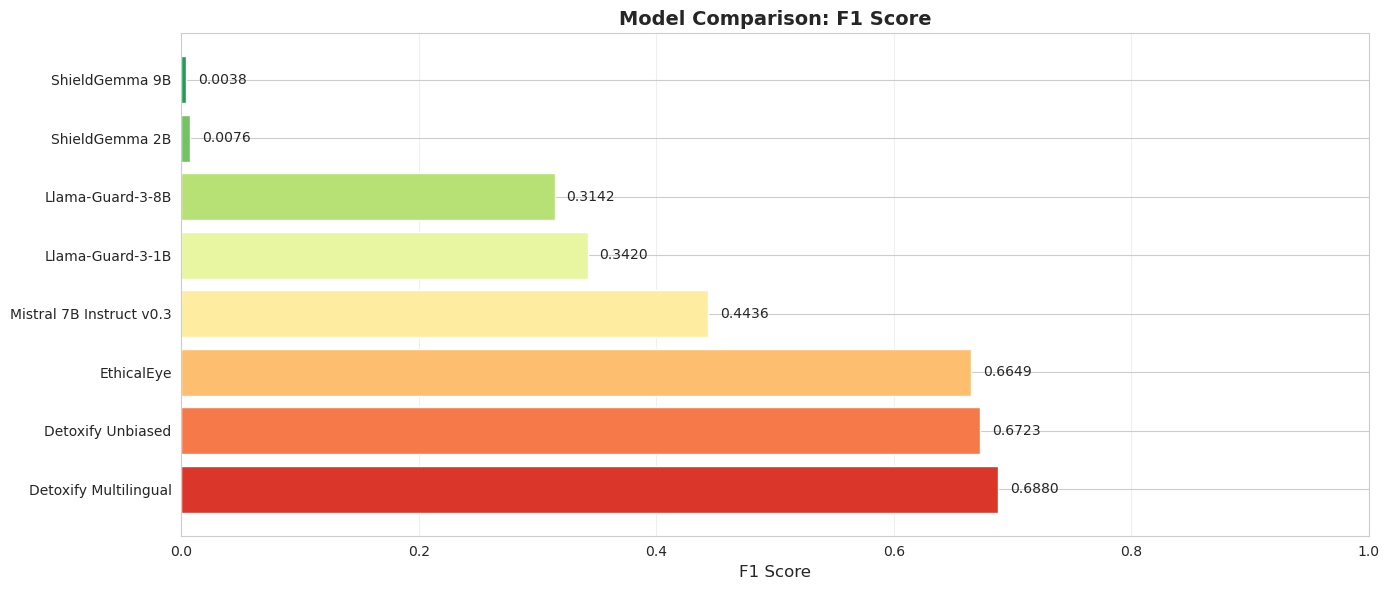

In [23]:
if all_metrics:
    plt.figure(figsize=(14, 6))
    models = [m.model_name for m in sorted(all_metrics, key=lambda x: x.f1, reverse=True)]
    f1_scores = [m.f1 for m in sorted(all_metrics, key=lambda x: x.f1, reverse=True)]
    
    colors = sns.color_palette("RdYlGn", len(models))
    plt.barh(models, f1_scores, color=colors)
    plt.xlabel('F1 Score', fontsize=12)
    plt.title('Model Comparison: F1 Score', fontsize=14, fontweight='bold')
    plt.xlim(0, 1.0)
    plt.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (model, score) in enumerate(zip(models, f1_scores)):
        plt.text(score + 0.01, i, f'{score:.4f}', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "f1_score_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

### 9.2 Precision-Recall Trade-off

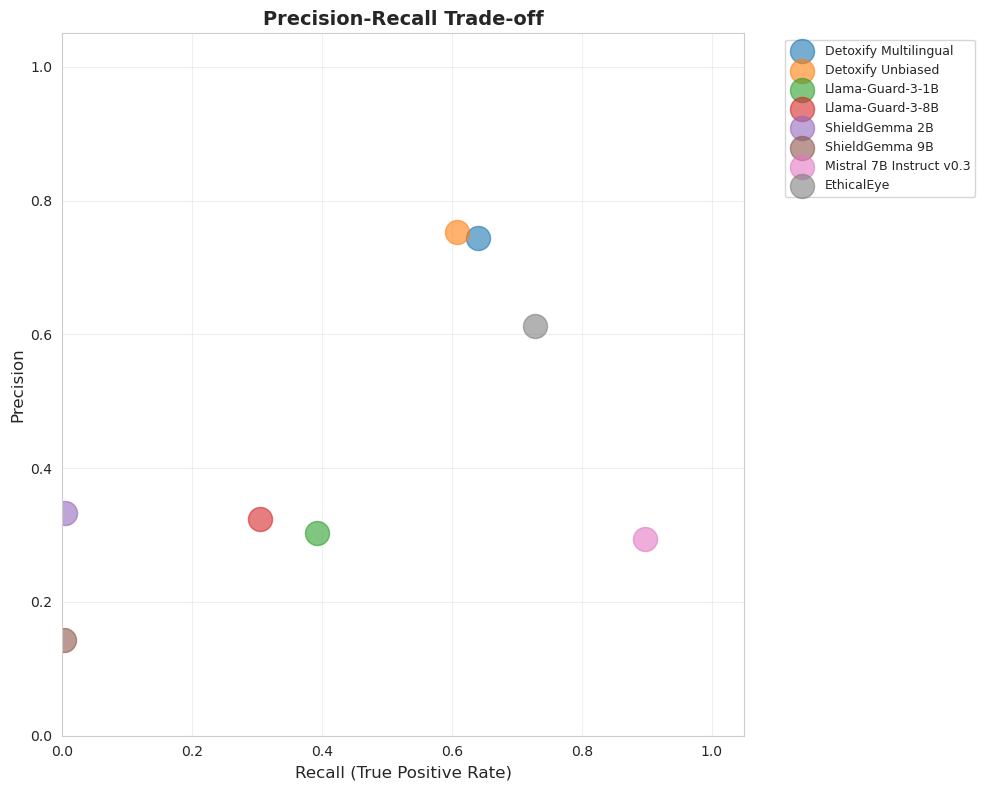

In [24]:
if all_metrics:
    plt.figure(figsize=(10, 8))
    
    for m in all_metrics:
        plt.scatter(m.recall, m.precision, s=300, alpha=0.6, label=m.model_name)
    
    plt.xlabel('Recall (True Positive Rate)', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Precision-Recall Trade-off', fontsize=14, fontweight='bold')
    plt.xlim(0, 1.05)
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "precision_recall_tradeoff.png", dpi=300, bbox_inches='tight')
    plt.show()

### 9.3 TPR vs FPR (ROC-style)

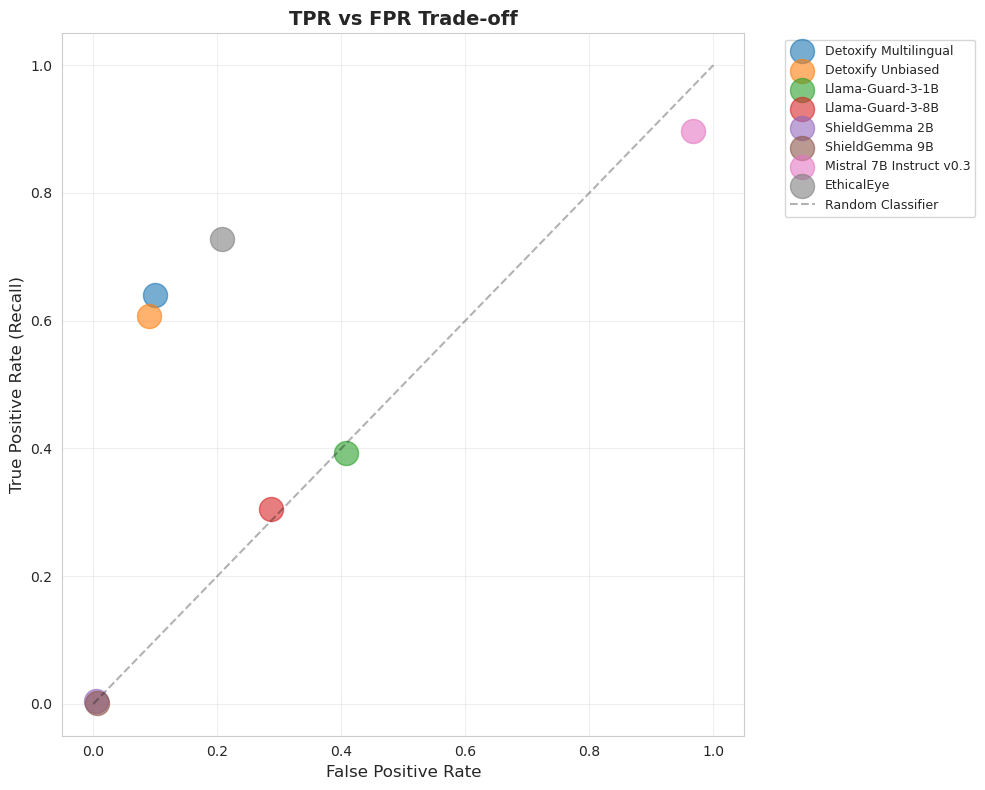

In [25]:
if all_metrics:
    plt.figure(figsize=(10, 8))
    
    for m in all_metrics:
        plt.scatter(m.false_positive_rate, m.true_positive_rate, s=300, alpha=0.6, label=m.model_name)
    
    # Diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random Classifier')
    
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate (Recall)', fontsize=12)
    plt.title('TPR vs FPR Trade-off', fontsize=14, fontweight='bold')
    plt.xlim(-0.05, 1.05)
    plt.ylim(-0.05, 1.05)
    plt.grid(alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "tpr_fpr_tradeoff.png", dpi=300, bbox_inches='tight')
    plt.show()

### 9.4 Inference Time Comparison

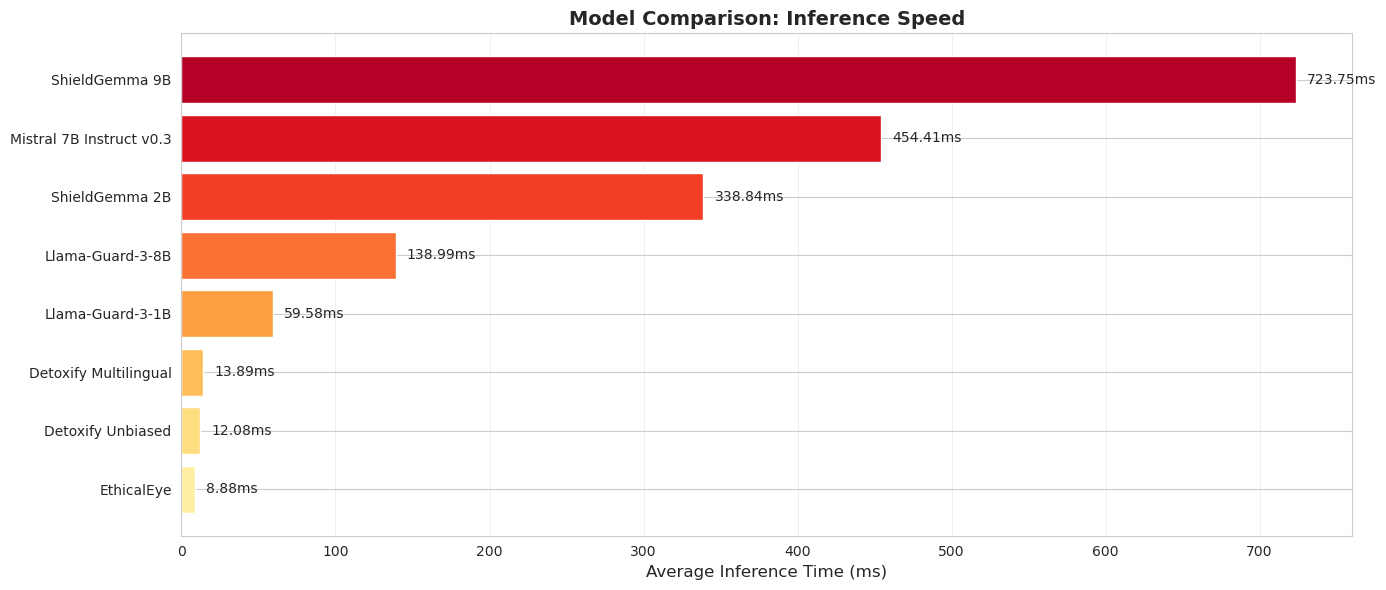

In [26]:
if all_metrics:
    plt.figure(figsize=(14, 6))
    models = [m.model_name for m in sorted(all_metrics, key=lambda x: x.avg_inference_time_ms)]
    times = [m.avg_inference_time_ms for m in sorted(all_metrics, key=lambda x: x.avg_inference_time_ms)]
    
    colors = sns.color_palette("YlOrRd", len(models))
    plt.barh(models, times, color=colors)
    plt.xlabel('Average Inference Time (ms)', fontsize=12)
    plt.title('Model Comparison: Inference Speed', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    
    for i, (model, time_val) in enumerate(zip(models, times)):
        plt.text(time_val + (max(times) * 0.01), i, f'{time_val:.2f}ms', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "inference_time_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

### 9.5 GPU Memory Usage

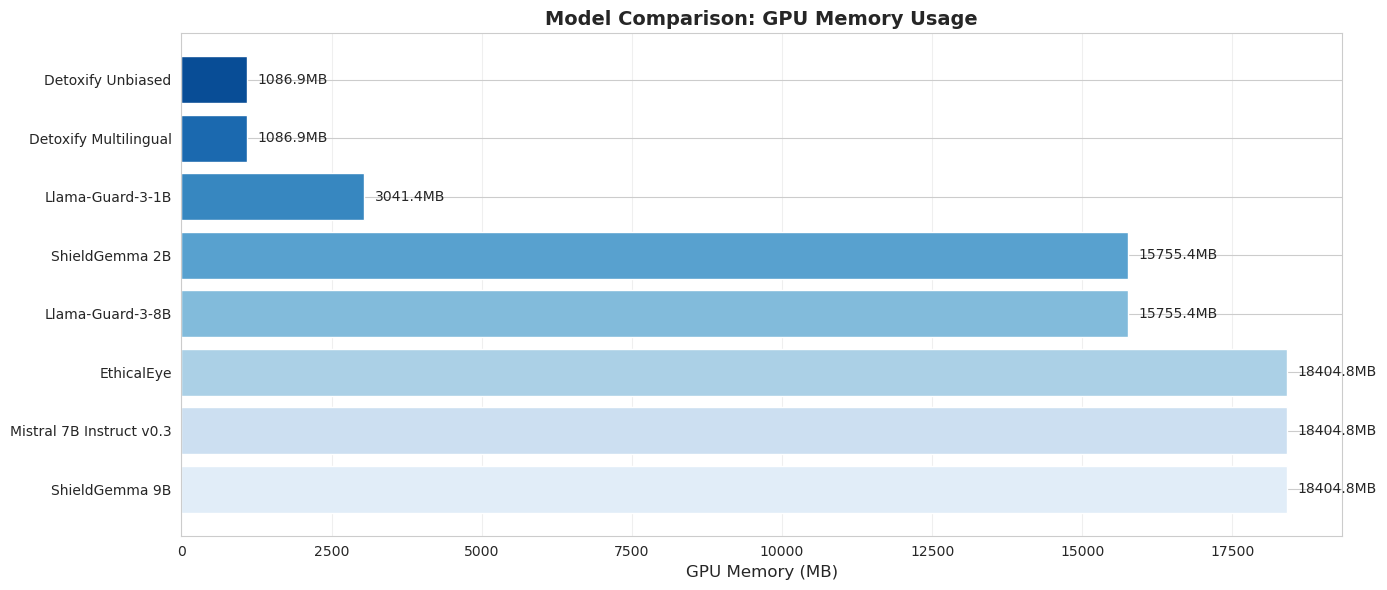

In [27]:
if all_metrics:
    plt.figure(figsize=(14, 6))
    models = [m.model_name for m in sorted(all_metrics, key=lambda x: x.gpu_memory_mb, reverse=True)]
    memory = [m.gpu_memory_mb for m in sorted(all_metrics, key=lambda x: x.gpu_memory_mb, reverse=True)]
    
    colors = sns.color_palette("Blues", len(models))
    plt.barh(models, memory, color=colors)
    plt.xlabel('GPU Memory (MB)', fontsize=12)
    plt.title('Model Comparison: GPU Memory Usage', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    
    for i, (model, mem) in enumerate(zip(models, memory)):
        plt.text(mem + (max(memory) * 0.01), i, f'{mem:.1f}MB', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "gpu_memory_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

### 9.6 Energy Consumption

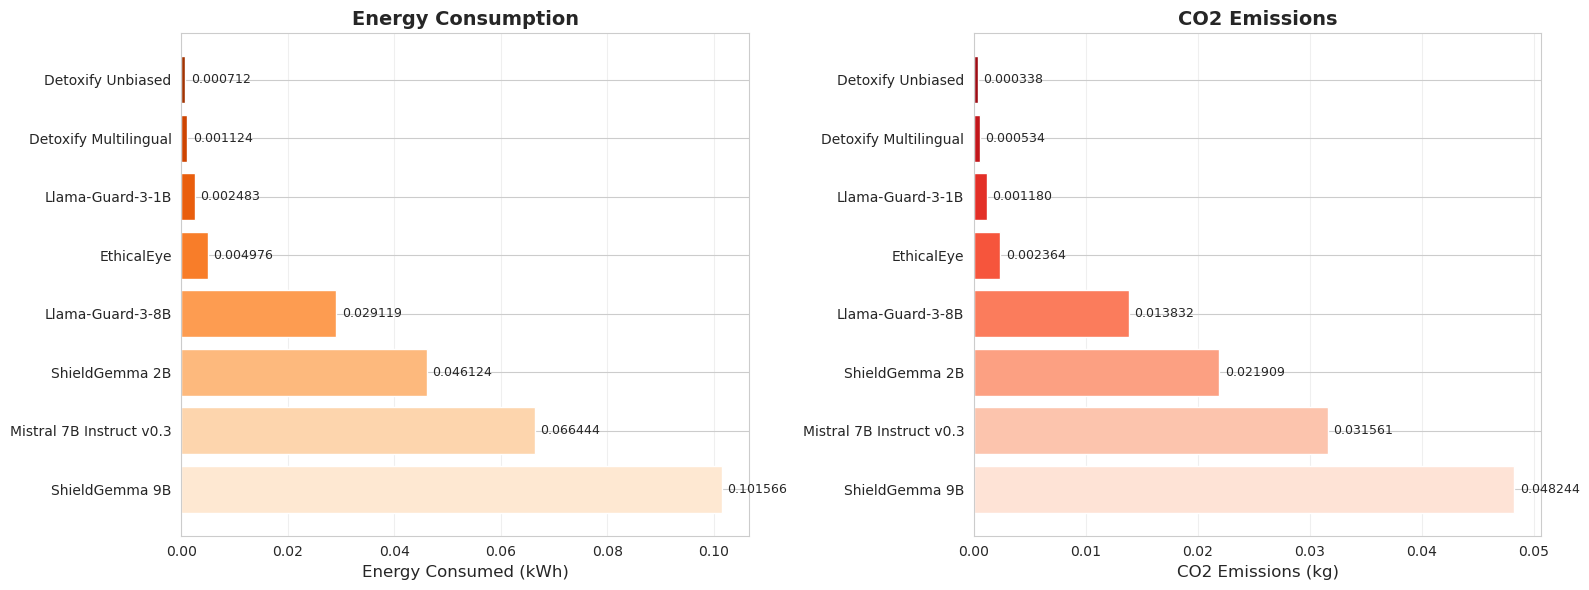

In [28]:
if all_metrics:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Energy consumption
    models = [m.model_name for m in sorted(all_metrics, key=lambda x: x.energy_consumed_kwh, reverse=True)]
    energy = [m.energy_consumed_kwh for m in sorted(all_metrics, key=lambda x: x.energy_consumed_kwh, reverse=True)]
    
    colors = sns.color_palette("Oranges", len(models))
    ax1.barh(models, energy, color=colors)
    ax1.set_xlabel('Energy Consumed (kWh)', fontsize=12)
    ax1.set_title('Energy Consumption', fontsize=14, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    
    for i, (model, e) in enumerate(zip(models, energy)):
        ax1.text(e + (max(energy) * 0.01), i, f'{e:.6f}', va='center', fontsize=9)
    
    # CO2 emissions
    co2 = [m.co2_emissions_kg for m in sorted(all_metrics, key=lambda x: x.co2_emissions_kg, reverse=True)]
    
    colors = sns.color_palette("Reds", len(models))
    ax2.barh(models, co2, color=colors)
    ax2.set_xlabel('CO2 Emissions (kg)', fontsize=12)
    ax2.set_title('CO2 Emissions', fontsize=14, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    
    for i, (model, c) in enumerate(zip(models, co2)):
        ax2.text(c + (max(co2) * 0.01), i, f'{c:.6f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "energy_co2_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

### 9.7 Multi-Metric Radar Chart

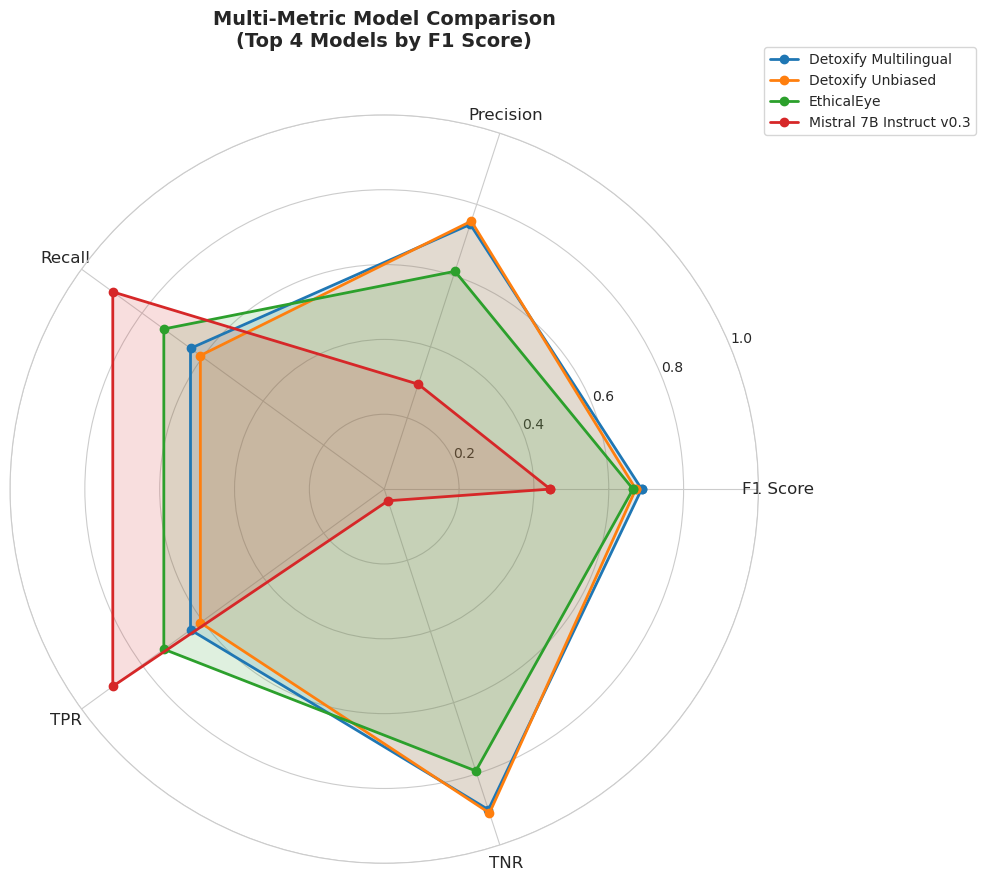

In [29]:
if all_metrics and len(all_metrics) >= 2:
    from math import pi
    
    # Select top 4 models by F1 score for clarity
    top_models = sorted(all_metrics, key=lambda x: x.f1, reverse=True)[:4]
    
    categories = ['F1 Score', 'Precision', 'Recall', 'TPR', 'TNR']
    N = len(categories)
    
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
    
    for m in top_models:
        values = [m.f1, m.precision, m.recall, m.true_positive_rate, m.true_negative_rate]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=m.model_name)
        ax.fill(angles, values, alpha=0.15)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=12)
    ax.set_ylim(0, 1)
    ax.set_title('Multi-Metric Model Comparison\n(Top 4 Models by F1 Score)', 
                 size=14, fontweight='bold', y=1.08)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
    ax.grid(True)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "multi_metric_radar.png", dpi=300, bbox_inches='tight')
    plt.show()

## 10. Export Complete Results

In [ ]:
if all_metrics:
    # Model information
    model_info_list = [
        ModelInfo(
            name="Detoxify Multilingual",
            model_type="detoxify",
            model_id="unitary/multilingual-toxic-xlm-roberta",
            size_params="~550M",
            supports_french=True,
            architecture="XLM-RoBERTa",
            description="Multilingual toxicity detection model"
        ),
        ModelInfo(
            name="Detoxify Unbiased",
            model_type="detoxify",
            model_id="unitary/unbiased-toxic-roberta",
            size_params="~125M",
            supports_french=False,
            architecture="RoBERTa",
            description="Unbiased English toxicity detection"
        ),
        ModelInfo(
            name="Llama Guard 3-1B",
            model_type="llama_guard",
            model_id="meta-llama/Llama-Guard-3-1B",
            size_params="1B",
            supports_french=True,
            architecture="Llama 3.2",
            description="Meta's safety classifier (1B)"
        ),
        ModelInfo(
            name="Llama Guard 3-8B",
            model_type="llama_guard",
            model_id="meta-llama/Llama-Guard-3-8B",
            size_params="8B",
            supports_french=True,
            architecture="Llama 3.1",
            description="Meta's safety classifier (8B)"
        ),
        ModelInfo(
            name="ShieldGemma 2B",
            model_type="shieldgemma",
            model_id="google/shieldgemma-2b",
            size_params="2B",
            supports_french=False,
            architecture="Gemma 2",
            description="Google's safety model (2B)"
        ),
        ModelInfo(
            name="ShieldGemma 9B",
            model_type="shieldgemma",
            model_id="google/shieldgemma-9b",
            size_params="9B",
            supports_french=False,
            architecture="Gemma 2",
            description="Google's safety model (9B)"
        ),
        ModelInfo(
            name="Mistral 7B Instruct v0.3",
            model_type="mistral",
            model_id="mistralai/Mistral-7B-Instruct-v0.3",
            size_params="7B",
            supports_french=True,
            architecture="Mistral",
            description="General-purpose LLM with moderation prompt"
        ),
        ModelInfo(
            name="EthicalEye",
            model_type="specialized",
            model_id="autopilot-ai/EthicalEye",
            size_params="~125M",
            supports_french=False,
            architecture="RoBERTa",
            description="Specialized content moderation classifier"
        ),
        ModelInfo(
            name="KoalaAI Text-Moderation",
            model_type="specialized",
            model_id="KoalaAI/Text-Moderation",
            size_params="~125M",
            supports_french=False,
            architecture="RoBERTa",
            description="Text moderation classifier"
        ),
        ModelInfo(
            name="CitizenLab XLM-RoBERTa",
            model_type="specialized",
            model_id="citizenlab/twitter-xlm-roberta-base-sentiment-finetunned",
            size_params="~270M",
            supports_french=True,
            architecture="XLM-RoBERTa",
            description="Multilingual sentiment classifier adapted for moderation"
        )
    ]
    
    # Create comprehensive JSON export
    export_data = {
        'experiment_metadata': {
            'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'dataset': str(DATASET_PATH),
            'samples_processed': len(samples),
            'device': DEVICE,
            'toxicity_threshold': TOXICITY_THRESHOLD,
            'total_experiment_time_seconds': total_experiment_time,
            'total_experiment_time_formatted': format_runtime(total_experiment_time)
        },
        'models_tested': [
            asdict(info) for info in model_info_list 
            if any(m.model_name == info.name for m in all_metrics)
        ],
        'performance_summary': [
            {
                'model_name': m.model_name,
                'classification_metrics': {
                    'accuracy': m.accuracy,
                    'precision': m.precision,
                    'recall': m.recall,
                    'f1_score': m.f1
                },
                'confusion_matrix': {
                    'true_positives': m.true_positives,
                    'false_positives': m.false_positives,
                    'true_negatives': m.true_negatives,
                    'false_negatives': m.false_negatives,
                    'true_positive_rate': m.true_positive_rate,
                    'false_positive_rate': m.false_positive_rate,
                    'true_negative_rate': m.true_negative_rate,
                    'false_negative_rate': m.false_negative_rate
                },
                'performance_metrics': {
                    'avg_inference_time_ms': m.avg_inference_time_ms,
                    'total_inference_time_seconds': m.total_inference_time_seconds,
                    'total_inference_time_formatted': format_runtime(m.total_inference_time_seconds),
                    'samples_per_second': m.samples_per_second
                },
                'resource_usage': {
                    'gpu_memory_peak_mb': m.gpu_memory_mb,
                    'cpu_utilization_avg_percent': m.cpu_percent_avg
                },
                'energy_metrics': {
                    'total_energy_kwh': m.energy_consumed_kwh,
                    'co2_emissions_kg': m.co2_emissions_kg
                },
                'errors': {
                    'count': m.errors,
                    'error_rate': m.error_rate
                }
            }
            for m in sorted(all_metrics, key=lambda x: x.f1, reverse=True)
        ],
        'totals': {
            'total_energy_kwh': sum(m.energy_consumed_kwh for m in all_metrics),
            'total_co2_kg': sum(m.co2_emissions_kg for m in all_metrics),
            'total_errors': sum(m.errors for m in all_metrics)
        }
    }
    
    # Save JSON
    json_path = OUTPUT_DIR / "complete_model_evaluation_results.json"
    with open(json_path, 'w') as f:
        # Convert numpy types to native Python types
        import numpy as np
        
        def convert_numpy(obj):
            if isinstance(obj, np.integer):
                return int(obj)
            elif isinstance(obj, np.floating):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            elif isinstance(obj, dict):
                return {k: convert_numpy(v) for k, v in obj.items()}
            elif isinstance(obj, list):
                return [convert_numpy(item) for item in obj]
            else:
                return obj
        
        export_data_clean = convert_numpy(export_data)
        json.dump(export_data_clean, f, indent=2)
    
    print(f"\n✅ Complete results saved to: {json_path}")
    print(f"\n📁 All outputs saved to: {OUTPUT_DIR}")
    print("\nGenerated files:")
    print("  - model_performance_summary.csv")
    print("  - model_confusion_matrix_summary.csv")
    print("  - model_resource_usage_summary.csv")
    print("  - complete_model_evaluation_results.json")
    print("  - f1_score_comparison.png")
    print("  - precision_recall_tradeoff.png")
    print("  - tpr_fpr_tradeoff.png")
    print("  - inference_time_comparison.png")
    print("  - gpu_memory_comparison.png")
    print("  - energy_co2_comparison.png")
    print("  - multi_metric_radar.png")

## 11. Key Findings & Recommendations

In [31]:
if all_metrics:
    print("\n" + "="*80)
    print("KEY FINDINGS")
    print("="*80)
    
    # Best F1 score
    best_f1 = max(all_metrics, key=lambda x: x.f1)
    print(f"\n🏆 Best F1 Score: {best_f1.model_name} ({best_f1.f1:.4f})")
    
    # Fastest model
    fastest = min(all_metrics, key=lambda x: x.avg_inference_time_ms)
    print(f"⚡ Fastest Model: {fastest.model_name} ({fastest.avg_inference_time_ms:.2f}ms/sample)")
    
    # Most memory efficient
    most_efficient = min(all_metrics, key=lambda x: x.gpu_memory_mb)
    print(f"💾 Most Memory Efficient: {most_efficient.model_name} ({most_efficient.gpu_memory_mb:.1f}MB)")
    
    # Best precision
    best_precision = max(all_metrics, key=lambda x: x.precision)
    print(f"🎯 Best Precision: {best_precision.model_name} ({best_precision.precision:.4f})")
    
    # Best recall
    best_recall = max(all_metrics, key=lambda x: x.recall)
    print(f"📊 Best Recall: {best_recall.model_name} ({best_recall.recall:.4f})")
    
    # Most energy efficient
    most_green = min(all_metrics, key=lambda x: x.energy_consumed_kwh)
    print(f"🌱 Most Energy Efficient: {most_green.model_name} ({most_green.energy_consumed_kwh:.6f}kWh)")
    
    print("\n" + "="*80)
    print("RECOMMENDATIONS FOR SHAREISH PLATFORM")
    print("="*80)
    print("""
Based on the evaluation results:

1. **For Production Deployment:**
   - Consider a two-tier system:
     * Fast pre-filter: Detoxify (high throughput, low latency)
     * Detailed analysis: Llama Guard 3 (French support, high accuracy)

2. **French Language Support:**
   - Prioritize models with native French support (Llama Guard 3, Mistral)
   - Detoxify Multilingual as fast initial filter

3. **Resource Constraints:**
   - Limited GPU: Use Detoxify or Llama Guard 3-1B
   - High accuracy needed: Llama Guard 3-8B or Mistral 7B

4. **False Positive/Negative Trade-offs:**
   - Adjust thresholds based on platform tolerance
   - Consider user appeals process for borderline cases

5. **Energy & Sustainability:**
   - For eco-conscious deployment, prefer lightweight models
   - Batch processing during off-peak hours for larger models
    """)
    
    print("="*80)


KEY FINDINGS

🏆 Best F1 Score: Detoxify Multilingual (0.6880)
⚡ Fastest Model: EthicalEye (8.88ms/sample)
💾 Most Memory Efficient: Detoxify Multilingual (1086.9MB)
🎯 Best Precision: Detoxify Unbiased (0.7530)
📊 Best Recall: Mistral 7B Instruct v0.3 (0.8966)
🌱 Most Energy Efficient: Detoxify Unbiased (0.000712kWh)

RECOMMENDATIONS FOR SHAREISH PLATFORM

Based on the evaluation results:

1. **For Production Deployment:**
   - Consider a two-tier system:
     * Fast pre-filter: Detoxify (high throughput, low latency)
     * Detailed analysis: Llama Guard 3 (French support, high accuracy)

2. **French Language Support:**
   - Prioritize models with native French support (Llama Guard 3, Mistral)
   - Detoxify Multilingual as fast initial filter

3. **Resource Constraints:**
   - Limited GPU: Use Detoxify or Llama Guard 3-1B
   - High accuracy needed: Llama Guard 3-8B or Mistral 7B

4. **False Positive/Negative Trade-offs:**
   - Adjust thresholds based on platform tolerance
   - Consider u